# Production-Level Deep Learning from Scratch

මේ notebook එකෙන් අපි **production-grade neural network framework** එකක් from scratch build කරනවා (NumPy only). Real-world projects වලදී use කරන **best practices** ටික implement කරමින් explain කරනවා.

### What Makes This "Production Level"?

| Feature | Basic Tutorial | This Notebook |
|---------|---------------|---------------|
| Architecture | Hardcoded layers | Modular, configurable Layer API |
| Data Handling | All data at once | Mini-batch DataLoader with shuffling |
| Training | Basic loop | Train/Val split, Early Stopping, LR Scheduling |
| Weight Init | Random | He/Xavier initialization |
| Regularization | None | L2, Dropout |
| Monitoring | Print loss | Training history, metrics dashboard |
| Gradient Issues | Ignored | Gradient clipping, numerical checking |
| Model Persistence | None | Save/Load with pickle |
| Evaluation | Accuracy only | Precision, Recall, F1, Confusion Matrix |
| Reproducibility | Random | Seed management |

---

## Table of Contents

1. [Config & Reproducibility](#1)
2. [Data Pipeline — DataLoader](#2)
3. [Activation Functions](#3)
4. [Layer API — Dense, Dropout, BatchNorm](#4)
5. [Loss Functions](#5)
6. [Optimizers — SGD, Adam](#6)
7. [Learning Rate Schedulers](#7)
8. [The Model Class](#8)
9. [Training Engine — Trainer](#9)
10. [Evaluation & Metrics](#10)
11. [End-to-End: Binary Classification](#11)
12. [End-to-End: Multi-class Classification](#12)
13. [Model Save & Load](#13)
14. [Summary](#14)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import os
from copy import deepcopy

print(" NumPy version:", np.__version__)
print(" All imports successful — no external DL libraries needed!")

🔧 NumPy version: 1.26.4
📦 All imports successful — no external DL libraries needed!


---

<a id="1"></a>
## 1. Config & Reproducibility

Production code වලදී **reproducibility** ගොඩක් important. Same seed දුන්නම same results ලැබෙන්න ඕනේ.

> **Why?** Debugging කරනකොට, model comparison කරනකොට, paper reproduce කරනකොට — exact same results ලැබෙන්න ඕනේ.

In [6]:
# ============================================================
# Configuration — Single source of truth
# ============================================================

class Config:
 """
 Production Practice: All hyperparameters in ONE place.
 
 Benefits:
 - Easy to modify experiments
 - Reproducible — save config with model
 - No magic numbers scattered in code
 """
 # Reproducibility
 SEED = 42
 
 # Data
 VAL_SPLIT = 0.2 # 20% for validation
 BATCH_SIZE = 32
 SHUFFLE = True
 
 # Training
 EPOCHS = 100
 LEARNING_RATE = 0.01
 
 # Regularization
 L2_LAMBDA = 1e-4 # Weight decay
 DROPOUT_RATE = 0.2 # Dropout probability
 GRAD_CLIP = 5.0 # Gradient clipping threshold
 
 # Early Stopping
 PATIENCE = 10 # Epochs to wait before stopping
 MIN_DELTA = 1e-4 # Minimum improvement to count


def set_seed(seed):
 """Set random seed for reproducibility."""
 np.random.seed(seed)

set_seed(Config.SEED)
print(f" Config loaded. Seed = {Config.SEED}")
print(f" Batch size: {Config.BATCH_SIZE}, LR: {Config.LEARNING_RATE}, Epochs: {Config.EPOCHS}")

✅ Config loaded. Seed = 42
   Batch size: 32, LR: 0.01, Epochs: 100


---

<a id="2"></a>
## 2. Data Pipeline — DataLoader

Production වලදී data whole එකම pass කරන්නේ නැහැ. **Mini-batches** use කරනවා:

- **Memory efficient** — large datasets RAM එකට fit වෙනවා
- **Better gradients** — stochastic noise helps escape local minima
- **Faster convergence** — frequent weight updates

```
Full Dataset (1000 samples)
 │
 ├── Shuffle
 │
 ├── Batch 1 (samples 0-31)
 ├── Batch 2 (samples 32-63)
 ├── Batch 3 (samples 64-95)
 ├── ...
 └── Batch 32 (samples 992-999) ← last batch may be smaller
```

In [7]:
# ============================================================
# DataLoader — Mini-batch iteration with shuffling
# ============================================================

class DataLoader:
 """
 Production-grade data loader.
 
 Features:
 - Mini-batch iteration
 - Epoch-level shuffling (prevents learning data order)
 - Train/Val split
 - Supports iteration protocol (for batch in loader:)
 """
 
 def __init__(self, X, y, batch_size=32, shuffle=True):
 self.X = X.astype(np.float64)
 self.y = y.astype(np.float64)
 self.batch_size = batch_size
 self.shuffle = shuffle
 self.n_samples = X.shape[0]
 
 def __iter__(self):
 """Yield batches. Shuffles at the start of each epoch."""
 indices = np.arange(self.n_samples)
 if self.shuffle:
 np.random.shuffle(indices)
 
 for start in range(0, self.n_samples, self.batch_size):
 end = min(start + self.batch_size, self.n_samples)
 batch_idx = indices[start:end]
 yield self.X[batch_idx], self.y[batch_idx]
 
 def __len__(self):
 """Number of batches per epoch."""
 return int(np.ceil(self.n_samples / self.batch_size))
 
 @staticmethod
 def train_val_split(X, y, val_ratio=0.2, seed=42):
 """
 Split data into train and validation sets.
 
 Production practice: ALWAYS have a validation set.
 Training loss alone is misleading (overfitting).
 """
 np.random.seed(seed)
 n = X.shape[0]
 indices = np.random.permutation(n)
 val_size = int(n * val_ratio)
 
 val_idx = indices[:val_size]
 train_idx = indices[val_size:]
 
 return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


# --- Demo ---
X_demo = np.random.randn(100, 3)
y_demo = np.random.randint(0, 2, (100, 1)).astype(float)

loader = DataLoader(X_demo, y_demo, batch_size=32)
print(f" DataLoader: {loader.n_samples} samples, {len(loader)} batches per epoch")

for i, (X_batch, y_batch) in enumerate(loader):
 print(f" Batch {i+1}: X shape = {X_batch.shape}, y shape = {y_batch.shape}")
 if i >= 2:
 print(f" ... ({len(loader) - 3} more batches)")
 break

✅ DataLoader: 100 samples, 4 batches per epoch
   Batch 1: X shape = (32, 3), y shape = (32, 1)
   Batch 2: X shape = (32, 3), y shape = (32, 1)
   Batch 3: X shape = (32, 3), y shape = (32, 1)
   ... (1 more batches)


---

<a id="3"></a>
## 3. Activation Functions

Production-level activations need:
- **Numerically stable** implementations (no overflow/underflow)
- Clean **forward/backward** interface
- Support for both **training** and **inference** modes

In [8]:
# ============================================================
# Activation Functions — Numerically Stable
# ============================================================

class ReLU:
 """
 ReLU: max(0, z)
 
 Production choice for hidden layers:
 - No vanishing gradient (unlike sigmoid)
 - Computationally cheap
 - Sparse activation (some neurons output 0 → efficient)
 
 Dying ReLU: if z ≤ 0 always, neuron is permanently dead.
 → Use He initialization to mitigate.
 """
 def forward(self, z, training=True):
 self.mask = (z > 0).astype(np.float64) # cache for backward
 return z * self.mask
 
 def backward(self, upstream):
 return upstream * self.mask # gradient is 1 where z > 0, else 0


class LeakyReLU:
 """
 Leaky ReLU: max(αz, z) where α = 0.01
 
 Fixes dying ReLU problem — small gradient even for negative z.
 """
 def __init__(self, alpha=0.01):
 self.alpha = alpha
 
 def forward(self, z, training=True):
 self.z = z
 return np.where(z > 0, z, self.alpha * z)
 
 def backward(self, upstream):
 return upstream * np.where(self.z > 0, 1.0, self.alpha)


class Sigmoid:
 """
 Sigmoid: 1 / (1 + e^(-z))
 
 Used for binary classification output layer.
 Not recommended for hidden layers (vanishing gradient).
 
 Numerically stable: uses np.clip to prevent overflow.
 """
 def forward(self, z, training=True):
 z_safe = np.clip(z, -500, 500)
 self.out = 1.0 / (1.0 + np.exp(-z_safe))
 return self.out
 
 def backward(self, upstream):
 return upstream * self.out * (1.0 - self.out)


class Softmax:
 """
 Softmax: e^(zᵢ) / Σe^(zⱼ)
 
 Used for multi-class classification output layer.
 Converts logits to probabilities (sum = 1).
 
 Numerically stable: subtracts max(z) before exp.
 """
 def forward(self, z, training=True):
 z_shifted = z - np.max(z, axis=1, keepdims=True) # stability trick!
 exp_z = np.exp(z_shifted)
 self.out = exp_z / np.sum(exp_z, axis=1, keepdims=True)
 return self.out
 
 def backward(self, upstream):
 # When paired with CrossEntropyLoss, gradient simplifies
 # to (predicted - true), so backward is handled in loss.
 return upstream


class Tanh:
 """Tanh: (e^z - e^(-z)) / (e^z + e^(-z)). Output range: (-1, 1)."""
 def forward(self, z, training=True):
 self.out = np.tanh(z)
 return self.out
 
 def backward(self, upstream):
 return upstream * (1.0 - self.out ** 2)


# Registry — map string names to activation classes
ACTIVATIONS = {
 'relu': ReLU,
 'leaky_relu': LeakyReLU,
 'sigmoid': Sigmoid,
 'softmax': Softmax,
 'tanh': Tanh,
}

print(" Activation functions registered:", list(ACTIVATIONS.keys()))

✅ Activation functions registered: ['relu', 'leaky_relu', 'sigmoid', 'softmax', 'tanh']


---

<a id="4"></a>
## 4. Layer API — Dense, Dropout, BatchNorm

Production networks use **modular layers** that can be stacked in any order.

### Layer Interface:

Every layer must implement:
- `forward(X, training)` — compute output
- `backward(upstream)` — compute gradients, return input gradient
- `params()` — return trainable parameters (for optimizer)

### Weight Initialization:

| Init Method | Formula | Best For |
|-------------|---------|----------|
| He | $W \sim N(0, \sqrt{2/n_{in}})$ | ReLU activations |
| Xavier | $W \sim N(0, \sqrt{1/n_{in}})$ | Sigmoid/Tanh |
| Zero | $b = 0$ | Biases |

In [9]:
# ============================================================
# Dense Layer — Fully Connected
# ============================================================

class Dense:
 """
 Fully connected layer with activation.
 
 Production features:
 - He/Xavier initialization based on activation
 - L2 regularization built in
 - Gradient clipping support
 - Clean parameter access for optimizer
 """
 
 def __init__(self, in_features, out_features, activation='relu', 
 l2_lambda=0.0, grad_clip=None):
 self.in_features = in_features
 self.out_features = out_features
 self.l2_lambda = l2_lambda
 self.grad_clip = grad_clip
 
 # --- Weight Initialization ---
 # He init for ReLU family, Xavier for others
 if activation in ('relu', 'leaky_relu'):
 scale = np.sqrt(2.0 / in_features) # He
 else:
 scale = np.sqrt(1.0 / in_features) # Xavier/Glorot
 
 self.W = np.random.randn(in_features, out_features) * scale
 self.b = np.zeros((1, out_features))
 
 # --- Activation ---
 act_cls = ACTIVATIONS.get(activation)
 self.activation = act_cls() if act_cls else None
 self.act_name = activation
 
 # --- Gradient storage ---
 self.dW = np.zeros_like(self.W)
 self.db = np.zeros_like(self.b)
 
 # --- Optimizer state (for Adam) ---
 self.optimizer_state = {}
 
 def forward(self, X, training=True):
 """Forward: z = X @ W + b, a = activation(z)"""
 self.X = X # cache for backward
 self.z = X @ self.W + self.b
 
 if self.activation:
 self.out = self.activation.forward(self.z, training)
 else:
 self.out = self.z # no activation (linear)
 
 return self.out
 
 def backward(self, upstream):
 """Backward: compute gradients and pass to previous layer."""
 m = self.X.shape[0]
 
 # Through activation
 if self.activation:
 dz = self.activation.backward(upstream)
 else:
 dz = upstream
 
 # Parameter gradients
 self.dW = (1/m) * (self.X.T @ dz)
 self.db = (1/m) * np.sum(dz, axis=0, keepdims=True)
 
 # L2 regularization gradient: adds λ * W to gradient
 if self.l2_lambda > 0:
 self.dW += self.l2_lambda * self.W
 
 # Gradient clipping: prevents exploding gradients
 if self.grad_clip:
 grad_norm = np.linalg.norm(self.dW)
 if grad_norm > self.grad_clip:
 self.dW = self.dW * (self.grad_clip / grad_norm)
 
 # Pass gradient to previous layer
 dX = dz @ self.W.T
 return dX
 
 def params(self):
 """Return trainable parameters and their gradients."""
 return [
 {'param': self.W, 'grad': self.dW, 'name': 'W', 'state': self.optimizer_state},
 {'param': self.b, 'grad': self.db, 'name': 'b', 'state': self.optimizer_state},
 ]
 
 def __repr__(self):
 act = self.act_name or 'linear'
 reg = f', L2={self.l2_lambda}' if self.l2_lambda else ''
 return f"Dense({self.in_features}→{self.out_features}, {act}{reg})"


print(" Dense layer class ready")

✅ Dense layer class ready


In [10]:
# ============================================================
# Dropout Layer — Regularization
# ============================================================

class Dropout:
 """
 Dropout regularization.
 
 During training: randomly zero out neurons with probability p.
 During inference: no dropout (use all neurons).
 
 Uses INVERTED dropout:
 - Scale activations by 1/(1-p) during training
 - No scaling needed at inference time
 
 This is the standard production approach (PyTorch, TF both use this).
 
 Why dropout works:
 - Prevents co-adaptation (neurons relying on each other)
 - Acts like training an ensemble of sub-networks
 - Reduces overfitting significantly
 """
 
 def __init__(self, rate=0.2):
 assert 0 <= rate < 1, "Dropout rate must be in [0, 1)"
 self.rate = rate
 
 def forward(self, X, training=True):
 if training and self.rate > 0:
 # Create binary mask: 1 = keep, 0 = drop
 self.mask = (np.random.rand(*X.shape) > self.rate).astype(np.float64)
 # Inverted dropout: scale by 1/(1-p)
 return X * self.mask / (1.0 - self.rate)
 else:
 return X # no dropout at inference
 
 def backward(self, upstream):
 return upstream * self.mask / (1.0 - self.rate)
 
 def params(self):
 return [] # no trainable parameters
 
 def __repr__(self):
 return f"Dropout(rate={self.rate})"


print(" Dropout layer ready")
print(f" Default rate: {Config.DROPOUT_RATE} (20% of neurons dropped per forward pass)")

✅ Dropout layer ready
   Default rate: 0.2 (20% of neurons dropped per forward pass)


---

<a id="5"></a>
## 5. Loss Functions

Production loss functions need:
- **Numerical stability** (log(0) = -inf, so we clip)
- **Vectorized** computation
- **L2 regularization** term built in

In [11]:
# ============================================================
# Loss Functions — Numerically Stable
# ============================================================

class BinaryCrossEntropy:
 """
 Binary Cross-Entropy Loss for binary classification.
 
 L = -(1/m) Σ [y·log(ŷ) + (1-y)·log(1-ŷ)]
 
 Production safety: clips predictions to [ε, 1-ε] to avoid log(0).
 """
 
 def forward(self, y_true, y_pred):
 self.y_true = y_true
 self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
 m = y_true.shape[0]
 loss = -(1/m) * np.sum(
 y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred)
 )
 return loss
 
 def backward(self):
 m = self.y_true.shape[0]
 return (-(self.y_true / self.y_pred) + (1 - self.y_true) / (1 - self.y_pred)) / m


class CategoricalCrossEntropy:
 """
 Cross-Entropy Loss for multi-class classification.
 Paired with Softmax output layer.
 
 L = -(1/m) Σ Σ yᵢⱼ · log(ŷᵢⱼ)
 
 Combined Softmax + CE gradient: ŷ - y (very clean!).
 """
 
 def forward(self, y_true, y_pred):
 self.y_true = y_true
 self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
 m = y_true.shape[0]
 loss = -(1/m) * np.sum(y_true * np.log(self.y_pred))
 return loss
 
 def backward(self):
 m = self.y_true.shape[0]
 return (self.y_pred - self.y_true) / m # softmax + CE combined gradient


class MSELoss:
 """Mean Squared Error for regression tasks."""
 
 def forward(self, y_true, y_pred):
 self.y_true = y_true
 self.y_pred = y_pred
 return np.mean(0.5 * (y_true - y_pred) ** 2)
 
 def backward(self):
 m = self.y_true.shape[0]
 return -(self.y_true - self.y_pred) / m


LOSSES = {
 'bce': BinaryCrossEntropy,
 'categorical_ce': CategoricalCrossEntropy,
 'mse': MSELoss,
}

print(" Loss functions registered:", list(LOSSES.keys()))

✅ Loss functions registered: ['bce', 'categorical_ce', 'mse']


---

<a id="6"></a>
## 6. Optimizers — SGD, Adam

Production models almost always use **Adam** optimizer. But understanding SGD first is important.

| Optimizer | Formula | Pros | Cons |
|-----------|---------|------|------|
| SGD | $w = w - \eta \cdot g$ | Simple, good generalization | Slow, sensitive to LR |
| SGD+Momentum | $v = \beta v + g$; $w = w - \eta v$ | Faster, smooths gradients | Extra hyperparameter |
| Adam | Adaptive LR per parameter | Fast, robust, less tuning | May generalize worse |

In [12]:
# ============================================================
# Optimizers
# ============================================================

class SGD:
 """
 Stochastic Gradient Descent with optional Momentum.
 
 Without momentum: w = w - lr * grad
 With momentum: v = β*v + grad
 w = w - lr * v
 
 Momentum acts like a ball rolling downhill — accumulates speed.
 """
 
 def __init__(self, lr=0.01, momentum=0.0):
 self.lr = lr
 self.initial_lr = lr # for LR scheduling
 self.momentum = momentum
 
 def update(self, layers):
 for layer in layers:
 for p in layer.params():
 param = p['param']
 grad = p['grad']
 state = p['state']
 key = f"v_{p['name']}"
 
 if self.momentum > 0:
 if key not in state:
 state[key] = np.zeros_like(param)
 state[key] = self.momentum * state[key] + grad
 param -= self.lr * state[key]
 else:
 param -= self.lr * grad


class Adam:
 """
 Adam Optimizer (Adaptive Moment Estimation).
 
 The INDUSTRY STANDARD optimizer. Combines:
 - Momentum (1st moment — mean of gradients)
 - RMSProp (2nd moment — mean of squared gradients)
 - Bias correction for early steps
 
 Each parameter gets its OWN adaptive learning rate!
 
 Default hyperparams (from the Adam paper):
 - β₁ = 0.9 (momentum decay)
 - β₂ = 0.999 (RMSProp decay)
 - ε = 1e-8 (numerical stability)
 """
 
 def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
 self.lr = lr
 self.initial_lr = lr
 self.beta1 = beta1
 self.beta2 = beta2
 self.epsilon = epsilon
 self.t = 0 # timestep
 
 def update(self, layers):
 self.t += 1
 
 for layer in layers:
 for p in layer.params():
 param = p['param']
 grad = p['grad']
 state = p['state']
 name = p['name']
 
 # Initialize moment estimates
 if f'm_{name}' not in state:
 state[f'm_{name}'] = np.zeros_like(param) # 1st moment
 state[f'v_{name}'] = np.zeros_like(param) # 2nd moment
 
 m = state[f'm_{name}']
 v = state[f'v_{name}']
 
 # Update biased moments
 m[:] = self.beta1 * m + (1 - self.beta1) * grad
 v[:] = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
 
 # Bias correction (important for early steps!)
 m_hat = m / (1 - self.beta1 ** self.t)
 v_hat = v / (1 - self.beta2 ** self.t)
 
 # Update parameters
 param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)


print(" Optimizers ready: SGD (with momentum), Adam")

✅ Optimizers ready: SGD (with momentum), Adam


---

<a id="7"></a>
## 7. Learning Rate Schedulers

Production training almost always uses **LR scheduling** — start with a larger LR, gradually reduce.

```
LR ↑
 │\ 
 │ \ Step Decay 
 │ \____ 
 │ \____ 
 │ \____ 
 └──────────────────→ Epochs 
```

In [13]:
# ============================================================
# Learning Rate Schedulers
# ============================================================

class StepDecay:
 """Reduce LR by factor every N epochs."""
 def __init__(self, optimizer, step_size=30, gamma=0.1):
 self.optimizer = optimizer
 self.step_size = step_size
 self.gamma = gamma
 
 def step(self, epoch):
 if epoch > 0 and epoch % self.step_size == 0:
 self.optimizer.lr *= self.gamma


class ReduceOnPlateau:
 """
 Reduce LR when metric stops improving.
 
 Production favorite: adapts to actual training progress.
 """
 def __init__(self, optimizer, patience=5, factor=0.5, min_lr=1e-6):
 self.optimizer = optimizer
 self.patience = patience
 self.factor = factor
 self.min_lr = min_lr
 self.best_loss = float('inf')
 self.wait = 0
 
 def step(self, val_loss):
 if val_loss < self.best_loss - 1e-4:
 self.best_loss = val_loss
 self.wait = 0
 else:
 self.wait += 1
 if self.wait >= self.patience:
 new_lr = max(self.optimizer.lr * self.factor, self.min_lr)
 if new_lr < self.optimizer.lr:
 self.optimizer.lr = new_lr
 print(f" LR reduced to {new_lr:.6f}")
 self.wait = 0


print(" LR Schedulers ready: StepDecay, ReduceOnPlateau")

✅ LR Schedulers ready: StepDecay, ReduceOnPlateau


---

<a id="8"></a>
## 8. The Model Class

Everything comes together in the **Model** class — similar to PyTorch's `nn.Module` or Keras's `Sequential`.

In [14]:
# ============================================================
# Model — Orchestrates layers, forward/backward, prediction
# ============================================================

class Model:
 """
 Sequential Neural Network Model.
 
 Similar interface to:
 - PyTorch: nn.Sequential
 - Keras: Sequential()
 
 Usage:
 model = Model()
 model.add(Dense(784, 128, 'relu'))
 model.add(Dropout(0.2))
 model.add(Dense(128, 10, 'softmax'))
 model.compile(loss='categorical_ce', optimizer='adam')
 """
 
 def __init__(self):
 self.layers = []
 self.loss_fn = None
 self.optimizer = None
 self.compiled = False
 
 def add(self, layer):
 """Add a layer to the model."""
 self.layers.append(layer)
 return self # allow chaining
 
 def compile(self, loss='bce', optimizer='adam', lr=0.001, **opt_kwargs):
 """
 Configure the model for training.
 
 Args:
 loss: 'bce', 'categorical_ce', or 'mse'
 optimizer: 'adam' or 'sgd'
 lr: learning rate
 """
 self.loss_fn = LOSSES[loss]()
 
 if optimizer == 'adam':
 self.optimizer = Adam(lr=lr, **opt_kwargs)
 elif optimizer == 'sgd':
 self.optimizer = SGD(lr=lr, **opt_kwargs)
 else:
 raise ValueError(f"Unknown optimizer: {optimizer}")
 
 self.compiled = True
 
 def forward(self, X, training=True):
 """Forward pass through all layers."""
 out = X
 for layer in self.layers:
 out = layer.forward(out, training=training)
 return out
 
 def backward(self, y_true, y_pred):
 """Backward pass — chain rule through all layers."""
 loss = self.loss_fn.forward(y_true, y_pred)
 grad = self.loss_fn.backward()
 
 for layer in reversed(self.layers):
 grad = layer.backward(grad)
 
 return loss
 
 def update(self):
 """Update weights using optimizer."""
 self.optimizer.update(self.layers)
 
 def predict(self, X):
 """Inference mode — no dropout, no batch norm noise."""
 return self.forward(X, training=False)
 
 def summary(self):
 """Print model architecture."""
 print("\n" + "=" * 55)
 print(" Model Summary")
 print("=" * 55)
 total_params = 0
 for i, layer in enumerate(self.layers):
 n_params = sum(p['param'].size for p in layer.params())
 total_params += n_params
 print(f" Layer {i+1}: {layer!r:<40} Params: {n_params:>6}")
 print("─" * 55)
 print(f" Total trainable parameters: {total_params:,}")
 print("=" * 55)


print(" Model class ready")

✅ Model class ready


---

<a id="9"></a>
## 9. Training Engine — Trainer

The **Trainer** handles the full training lifecycle:

```
┌─────────────────────────────────────────────────┐
│ TRAINING LOOP │
│ │
│ For each epoch: │
│ For each batch: │
│ 1. Forward Pass │
│ 2. Compute Loss │
│ 3. Backward Pass │
│ 4. Update Weights │
│ Validate on val set │
│ LR Scheduling │
│ Early Stopping check │
│ Save best model │
└─────────────────────────────────────────────────┘
```

In [15]:
# ============================================================
# Trainer — Full Training Engine
# ============================================================

class EarlyStopping:
 """
 Stop training when validation loss stops improving.
 
 Saves the best model weights and restores them at the end.
 Prevents overfitting by stopping before the model memorizes training data.
 """
 def __init__(self, patience=10, min_delta=1e-4):
 self.patience = patience
 self.min_delta = min_delta
 self.best_loss = float('inf')
 self.wait = 0
 self.best_weights = None
 self.stopped_epoch = 0
 
 def check(self, val_loss, model, epoch):
 if val_loss < self.best_loss - self.min_delta:
 self.best_loss = val_loss
 self.wait = 0
 # Save best weights
 self.best_weights = [
 {p['name']: p['param'].copy() for p in layer.params()}
 for layer in model.layers
 ]
 return False # don't stop
 else:
 self.wait += 1
 if self.wait >= self.patience:
 self.stopped_epoch = epoch
 return True # stop!
 return False
 
 def restore_best(self, model):
 """Restore the best weights."""
 if self.best_weights:
 for layer, saved in zip(model.layers, self.best_weights):
 for p in layer.params():
 if p['name'] in saved:
 p['param'][:] = saved[p['name']]


class Trainer:
 """
 Production Training Engine.
 
 Features:
 - Mini-batch training
 - Train/Val monitoring
 - Early stopping
 - LR scheduling
 - Training history for analysis
 - Progress display
 """
 
 def __init__(self, model, early_stopping=None, lr_scheduler=None):
 assert model.compiled, "Model must be compiled before training!"
 self.model = model
 self.early_stopping = early_stopping
 self.lr_scheduler = lr_scheduler
 
 # Training history
 self.history = {
 'train_loss': [],
 'val_loss': [],
 'train_acc': [],
 'val_acc': [],
 'lr': [],
 }
 
 def _compute_accuracy(self, y_true, y_pred):
 """Compute accuracy for classification tasks."""
 if y_pred.shape[1] == 1: # binary
 predictions = (y_pred >= 0.5).astype(int)
 else: # multi-class
 predictions = np.argmax(y_pred, axis=1).reshape(-1, 1)
 y_true = np.argmax(y_true, axis=1).reshape(-1, 1)
 return np.mean(predictions == y_true)
 
 def fit(self, train_loader, val_loader=None, epochs=100):
 """
 Train the model.
 
 Args:
 train_loader: DataLoader for training data
 val_loader: DataLoader for validation data (optional but recommended)
 epochs: number of training epochs
 """
 print("\n" + "═" * 70)
 print(" TRAINING STARTED")
 print("═" * 70)
 self.model.summary()
 print()
 
 start_time = time.time()
 
 for epoch in range(epochs):
 epoch_start = time.time()
 
 # ── Training Phase ──
 train_losses = []
 train_preds, train_labels = [], []
 
 for X_batch, y_batch in train_loader:
 # Forward
 y_pred = self.model.forward(X_batch, training=True)
 
 # Backward + Update
 loss = self.model.backward(y_batch, y_pred)
 self.model.update()
 
 train_losses.append(loss)
 train_preds.append(y_pred)
 train_labels.append(y_batch)
 
 # Epoch metrics
 avg_train_loss = np.mean(train_losses)
 all_train_preds = np.vstack(train_preds)
 all_train_labels = np.vstack(train_labels)
 train_acc = self._compute_accuracy(all_train_labels, all_train_preds)
 
 self.history['train_loss'].append(avg_train_loss)
 self.history['train_acc'].append(train_acc)
 self.history['lr'].append(self.model.optimizer.lr)
 
 # ── Validation Phase ──
 val_loss, val_acc = 0, 0
 if val_loader:
 val_losses = []
 val_preds, val_labels = [], []
 
 for X_batch, y_batch in val_loader:
 y_pred = self.model.predict(X_batch) # no dropout
 loss = self.model.loss_fn.forward(y_batch, y_pred)
 val_losses.append(loss)
 val_preds.append(y_pred)
 val_labels.append(y_batch)
 
 val_loss = np.mean(val_losses)
 all_val_preds = np.vstack(val_preds)
 all_val_labels = np.vstack(val_labels)
 val_acc = self._compute_accuracy(all_val_labels, all_val_preds)
 
 self.history['val_loss'].append(val_loss)
 self.history['val_acc'].append(val_acc)
 
 # ── Progress Display ──
 elapsed = time.time() - epoch_start
 if (epoch + 1) % max(1, epochs // 20) == 0 or epoch == 0 or epoch == epochs - 1:
 msg = f" Epoch {epoch+1:>4}/{epochs} │ "
 msg += f"Loss: {avg_train_loss:.4f} "
 msg += f"Acc: {train_acc:.3f}"
 if val_loader:
 msg += f" │ Val Loss: {val_loss:.4f} Val Acc: {val_acc:.3f}"
 msg += f" │ {elapsed:.1f}s"
 print(msg)
 
 # ── LR Scheduling ──
 if self.lr_scheduler:
 if isinstance(self.lr_scheduler, ReduceOnPlateau) and val_loader:
 self.lr_scheduler.step(val_loss)
 elif isinstance(self.lr_scheduler, StepDecay):
 self.lr_scheduler.step(epoch)
 
 # ── Early Stopping ──
 if self.early_stopping and val_loader:
 if self.early_stopping.check(val_loss, self.model, epoch):
 print(f"\n Early stopping at epoch {epoch+1} (patience={self.early_stopping.patience})")
 self.early_stopping.restore_best(self.model)
 print(f" Best weights restored (val_loss={self.early_stopping.best_loss:.4f})")
 break
 
 total_time = time.time() - start_time
 print(f"\n Training complete in {total_time:.1f}s")
 print(f" Final — Train Loss: {self.history['train_loss'][-1]:.4f}, Acc: {self.history['train_acc'][-1]:.3f}")
 if val_loader:
 print(f" Final — Val Loss: {self.history['val_loss'][-1]:.4f}, Acc: {self.history['val_acc'][-1]:.3f}")
 
 return self.history


print(" Trainer engine ready — with EarlyStopping, LR scheduling, history tracking")

✅ Trainer engine ready — with EarlyStopping, LR scheduling, history tracking


---

<a id="10"></a>
## 10. Evaluation & Metrics

Production evaluation goes beyond accuracy:

| Metric | Formula | When to Use |
|--------|---------|-------------|
| Accuracy | (TP+TN) / Total | Balanced classes |
| Precision | TP / (TP+FP) | Cost of false positives is high |
| Recall | TP / (TP+FN) | Cost of missing positives is high |
| F1 Score | 2·P·R / (P+R) | Imbalanced classes |

In [16]:
# ============================================================
# Evaluation Metrics + Visualization
# ============================================================

def evaluate_binary(y_true, y_pred_prob, threshold=0.5):
 """Full evaluation suite for binary classification."""
 y_pred = (y_pred_prob >= threshold).astype(int).flatten()
 y_true = y_true.flatten().astype(int)
 
 # Confusion matrix
 TP = np.sum((y_pred == 1) & (y_true == 1))
 TN = np.sum((y_pred == 0) & (y_true == 0))
 FP = np.sum((y_pred == 1) & (y_true == 0))
 FN = np.sum((y_pred == 0) & (y_true == 1))
 
 accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
 precision = TP / (TP + FP) if (TP + FP) > 0 else 0
 recall = TP / (TP + FN) if (TP + FN) > 0 else 0
 f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
 
 return {
 'accuracy': accuracy, 'precision': precision,
 'recall': recall, 'f1': f1,
 'confusion_matrix': np.array([[TN, FP], [FN, TP]])
 }


def plot_training_history(history):
 """Plot training curves — the production monitoring dashboard."""
 has_val = len(history.get('val_loss', [])) > 0
 n_plots = 3 if has_val else 2
 
 fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
 
 # Loss
 axes[0].plot(history['train_loss'], label='Train Loss', color='#6366f1', linewidth=2)
 if has_val:
 axes[0].plot(history['val_loss'], label='Val Loss', color='#f43f5e', linewidth=2, linestyle='--')
 axes[0].set_title(' Loss', fontsize=13, fontweight='bold')
 axes[0].set_xlabel('Epoch')
 axes[0].set_ylabel('Loss')
 axes[0].legend()
 axes[0].grid(True, alpha=0.3)
 
 # Accuracy
 axes[1].plot(history['train_acc'], label='Train Acc', color='#22c55e', linewidth=2)
 if has_val:
 axes[1].plot(history['val_acc'], label='Val Acc', color='#f59e0b', linewidth=2, linestyle='--')
 axes[1].set_title(' Accuracy', fontsize=13, fontweight='bold')
 axes[1].set_xlabel('Epoch')
 axes[1].set_ylabel('Accuracy')
 axes[1].legend()
 axes[1].grid(True, alpha=0.3)
 
 # Learning Rate
 if n_plots == 3:
 axes[2].plot(history['lr'], color='#8b5cf6', linewidth=2)
 axes[2].set_title(' Learning Rate', fontsize=13, fontweight='bold')
 axes[2].set_xlabel('Epoch')
 axes[2].set_ylabel('LR')
 axes[2].grid(True, alpha=0.3)
 
 plt.tight_layout()
 plt.show()


def plot_confusion_matrix(cm, labels=['Negative', 'Positive']):
 """Plot confusion matrix heatmap."""
 fig, ax = plt.subplots(figsize=(6, 5))
 im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
 
 ax.set_xticks([0, 1])
 ax.set_yticks([0, 1])
 ax.set_xticklabels(labels, fontsize=12)
 ax.set_yticklabels(labels, fontsize=12)
 ax.set_xlabel('Predicted', fontsize=13)
 ax.set_ylabel('Actual', fontsize=13)
 ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
 
 for i in range(2):
 for j in range(2):
 color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
 ax.text(j, i, str(cm[i, j]), ha='center', va='center',
 fontsize=20, fontweight='bold', color=color)
 
 plt.colorbar(im)
 plt.tight_layout()
 plt.show()


print(" Evaluation suite ready — accuracy, precision, recall, F1, confusion matrix")

✅ Evaluation suite ready — accuracy, precision, recall, F1, confusion matrix


---

<a id="11"></a>
## 11. End-to-End: Binary Classification (Moons Dataset)

දැන් අපි build කරපු framework එකෙන් **real classification problem** එකක් solve කරමු!

### Dataset: Two Moons (Non-linear separable)

📊 Dataset: Moons
   Train: 640 samples
   Val:   160 samples
   Features: 2


/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


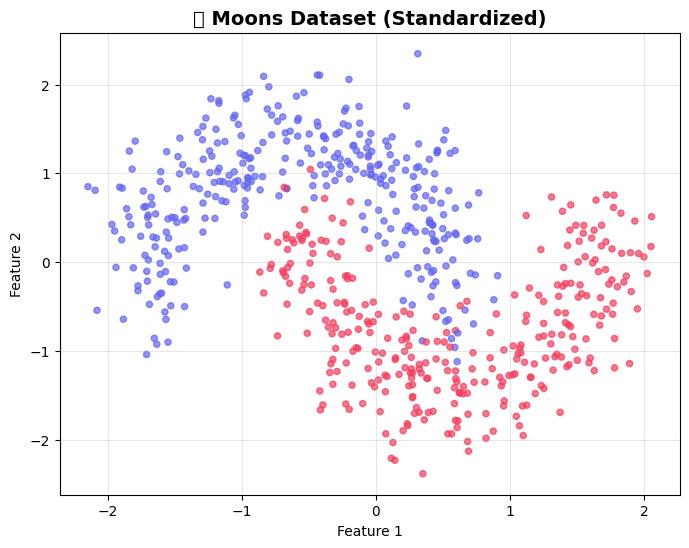

In [17]:
# ============================================================
# Generate Moons Dataset
# ============================================================

def make_moons(n_samples=500, noise=0.2, seed=42):
 """Generate two interleaving half circles (moons)."""
 np.random.seed(seed)
 n = n_samples // 2
 
 # First moon
 theta1 = np.linspace(0, np.pi, n)
 x1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
 
 # Second moon (shifted)
 theta2 = np.linspace(0, np.pi, n)
 x2 = np.column_stack([1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5])
 
 X = np.vstack([x1, x2]) + np.random.randn(n_samples, 2) * noise
 y = np.hstack([np.zeros(n), np.ones(n)]).reshape(-1, 1)
 
 # Shuffle
 idx = np.random.permutation(n_samples)
 return X[idx], y[idx]


# Generate data
X_moons, y_moons = make_moons(n_samples=800, noise=0.2)

# Standardize (ALWAYS standardize in production!)
X_mean, X_std = X_moons.mean(axis=0), X_moons.std(axis=0)
X_moons = (X_moons - X_mean) / X_std

# Train/Val split
X_train, y_train, X_val, y_val = DataLoader.train_val_split(
 X_moons, y_moons, val_ratio=0.2
)

print(f" Dataset: Moons")
print(f" Train: {X_train.shape[0]} samples")
print(f" Val: {X_val.shape[0]} samples")
print(f" Features: {X_train.shape[1]}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#6366f1' if label == 0 else '#f43f5e' for label in y_train.flatten()]
ax.scatter(X_train[:, 0], X_train[:, 1], c=colors, s=20, alpha=0.7)
ax.set_title(' Moons Dataset (Standardized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
# ============================================================
# Build, Compile & Train — Production Style
# ============================================================

set_seed(Config.SEED)

# --- Build Model ---
model = Model()
model.add(Dense(2, 32, activation='relu', l2_lambda=1e-4, grad_clip=5.0))
model.add(Dropout(rate=0.2))
model.add(Dense(32, 16, activation='relu', l2_lambda=1e-4, grad_clip=5.0))
model.add(Dropout(rate=0.1))
model.add(Dense(16, 1, activation='sigmoid'))

# --- Compile ---
model.compile(loss='bce', optimizer='adam', lr=0.005)

# --- Create DataLoaders ---
train_loader = DataLoader(X_train, y_train, batch_size=32, shuffle=True)
val_loader = DataLoader(X_val, y_val, batch_size=64, shuffle=False)

# --- Setup Training Accessories ---
early_stop = EarlyStopping(patience=15, min_delta=1e-4)
lr_sched = ReduceOnPlateau(model.optimizer, patience=8, factor=0.5)

# --- Train! ---
trainer = Trainer(model, early_stopping=early_stop, lr_scheduler=lr_sched)
history = trainer.fit(train_loader, val_loader, epochs=150)


══════════════════════════════════════════════════════════════════════
  🚀 TRAINING STARTED
══════════════════════════════════════════════════════════════════════

  Model Summary
  Layer 1: Dense(2→32, relu, L2=0.0001)             Params:     96
  Layer 2: Dropout(rate=0.2)                        Params:      0
  Layer 3: Dense(32→16, relu, L2=0.0001)            Params:    528
  Layer 4: Dropout(rate=0.1)                        Params:      0
  Layer 5: Dense(16→1, sigmoid)                     Params:     17
───────────────────────────────────────────────────────
  Total trainable parameters: 641

  Epoch    1/150 │ Loss: 0.4545 Acc: 0.761 │ Val Loss: 0.3105 Val Acc: 0.819 │ 0.1s
  Epoch    7/150 │ Loss: 0.2628 Acc: 0.883 │ Val Loss: 0.2274 Val Acc: 0.881 │ 0.0s
  Epoch   14/150 │ Loss: 0.1431 Acc: 0.952 │ Val Loss: 0.1103 Val Acc: 0.956 │ 0.0s
  Epoch   21/150 │ Loss: 0.1197 Acc: 0.953 │ Val Loss: 0.0734 Val Acc: 0.975 │ 0.0s
  Epoch   28/150 │ Loss: 0.1041 Acc: 0.966 │ Val Loss: 0.

/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu San

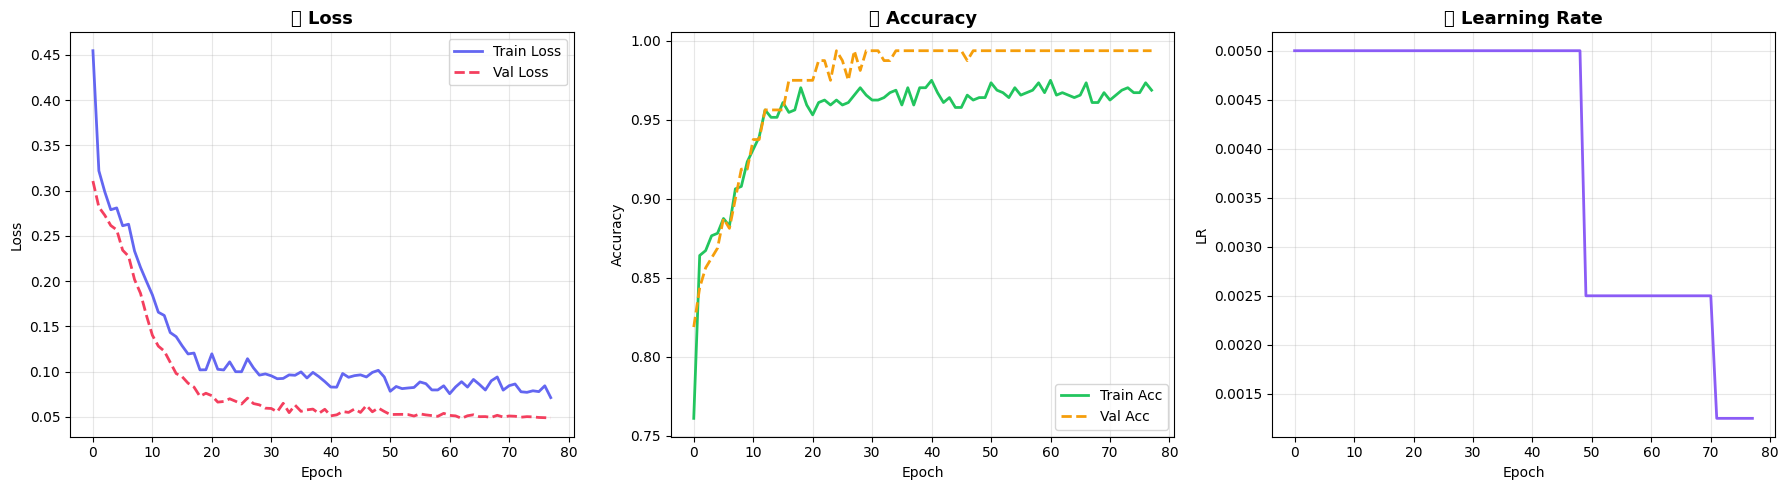


  📊 VALIDATION METRICS
  Accuracy:  0.9938
  Precision: 0.9888
  Recall:    1.0000
  F1 Score:  0.9944


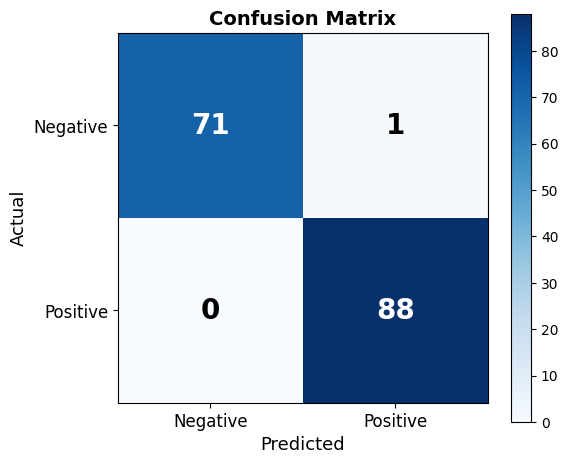

In [19]:
# ============================================================
# Evaluate & Visualize Results
# ============================================================

# Training history
plot_training_history(history)

# Metrics on validation set
y_val_pred = model.predict(X_val)
metrics = evaluate_binary(y_val, y_val_pred)

print("\n" + "=" * 45)
print(" VALIDATION METRICS")
print("=" * 45)
print(f" Accuracy: {metrics['accuracy']:.4f}")
print(f" Precision: {metrics['precision']:.4f}")
print(f" Recall: {metrics['recall']:.4f}")
print(f" F1 Score: {metrics['f1']:.4f}")

# Confusion Matrix
plot_confusion_matrix(metrics['confusion_matrix'])

/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/3447318853.py:30: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


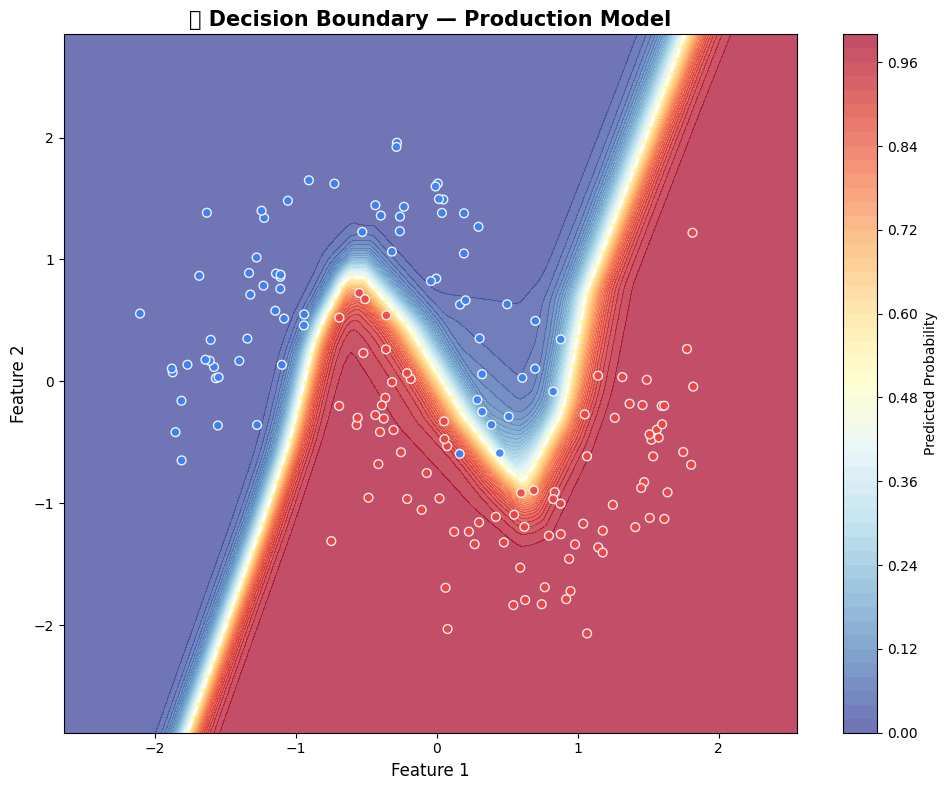

In [20]:
# ============================================================
# Decision Boundary Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Create mesh
xx, yy = np.meshgrid(
 np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 200),
 np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

# Plot
contour = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.7)
plt.colorbar(contour, label='Predicted Probability')

# Decision boundary line
ax.contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2, linestyles='--')

# Scatter data
colors_val = ['#3b82f6' if l == 0 else '#ef4444' for l in y_val.flatten()]
ax.scatter(X_val[:, 0], X_val[:, 1], c=colors_val, s=40, edgecolors='white', 
 linewidths=1, zorder=5, alpha=0.9)

ax.set_title(' Decision Boundary — Production Model', fontsize=15, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
plt.tight_layout()
plt.show()

---

<a id="12"></a>
## 12. End-to-End: Multi-class Classification (Spiral Dataset)

📊 Spiral Dataset: 600 samples, 3 classes
   Train: 480, Val: 120


/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


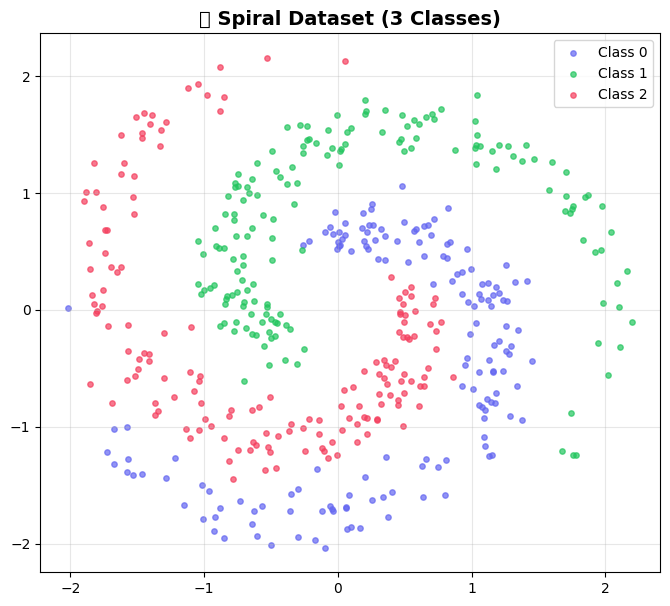

In [21]:
# ============================================================
# Spiral Dataset — 3 classes
# ============================================================

def make_spiral(n_samples_per_class=200, n_classes=3, noise=0.5, seed=42):
 """Generate spiral dataset with N classes."""
 np.random.seed(seed)
 X, y = [], []
 for c in range(n_classes):
 r = np.linspace(0.2, 1.0, n_samples_per_class)
 theta = np.linspace(c * 4, (c + 1) * 4, n_samples_per_class) + np.random.randn(n_samples_per_class) * noise
 X.append(np.column_stack([r * np.sin(theta), r * np.cos(theta)]))
 y.append(np.full(n_samples_per_class, c))
 
 X = np.vstack(X)
 y = np.concatenate(y)
 
 # One-hot encode
 y_onehot = np.zeros((len(y), n_classes))
 y_onehot[np.arange(len(y)), y.astype(int)] = 1
 
 # Shuffle
 idx = np.random.permutation(len(X))
 return X[idx], y_onehot[idx]


# Generate
X_spiral, y_spiral = make_spiral(n_samples_per_class=200, n_classes=3, noise=0.4)
X_spiral = (X_spiral - X_spiral.mean(0)) / X_spiral.std(0)

X_train_s, y_train_s, X_val_s, y_val_s = DataLoader.train_val_split(X_spiral, y_spiral)

print(f" Spiral Dataset: {X_spiral.shape[0]} samples, {y_spiral.shape[1]} classes")
print(f" Train: {X_train_s.shape[0]}, Val: {X_val_s.shape[0]}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 7))
class_colors = ['#6366f1', '#22c55e', '#f43f5e']
y_labels = np.argmax(y_train_s, axis=1)
for c in range(3):
 mask = y_labels == c
 ax.scatter(X_train_s[mask, 0], X_train_s[mask, 1], c=class_colors[c], 
 s=15, alpha=0.7, label=f'Class {c}')
ax.set_title(' Spiral Dataset (3 Classes)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [22]:
# ============================================================
# Multi-Class Model — Train & Evaluate
# ============================================================

set_seed(Config.SEED)

# Build
model_mc = Model()
model_mc.add(Dense(2, 64, activation='relu', l2_lambda=1e-4))
model_mc.add(Dropout(0.15))
model_mc.add(Dense(64, 32, activation='relu', l2_lambda=1e-4))
model_mc.add(Dense(32, 3, activation='softmax')) # 3 classes!

# Compile
model_mc.compile(loss='categorical_ce', optimizer='adam', lr=0.005)

# Train
train_loader_s = DataLoader(X_train_s, y_train_s, batch_size=32)
val_loader_s = DataLoader(X_val_s, y_val_s, batch_size=64, shuffle=False)

early_stop_mc = EarlyStopping(patience=20)
lr_sched_mc = ReduceOnPlateau(model_mc.optimizer, patience=10, factor=0.5)

trainer_mc = Trainer(model_mc, early_stopping=early_stop_mc, lr_scheduler=lr_sched_mc)
history_mc = trainer_mc.fit(train_loader_s, val_loader_s, epochs=200)


══════════════════════════════════════════════════════════════════════
  🚀 TRAINING STARTED
══════════════════════════════════════════════════════════════════════

  Model Summary
  Layer 1: Dense(2→64, relu, L2=0.0001)             Params:    192
  Layer 2: Dropout(rate=0.15)                       Params:      0
  Layer 3: Dense(64→32, relu, L2=0.0001)            Params:   2080
  Layer 4: Dense(32→3, softmax)                     Params:     99
───────────────────────────────────────────────────────
  Total trainable parameters: 2,371

  Epoch    1/200 │ Loss: 1.0798 Acc: 0.456 │ Val Loss: 0.8180 Val Acc: 0.533 │ 0.0s
  Epoch   10/200 │ Loss: 0.5171 Acc: 0.858 │ Val Loss: 0.4242 Val Acc: 0.917 │ 0.0s
  Epoch   20/200 │ Loss: 0.2168 Acc: 0.948 │ Val Loss: 0.1554 Val Acc: 0.933 │ 0.0s
  Epoch   30/200 │ Loss: 0.1536 Acc: 0.954 │ Val Loss: 0.1156 Val Acc: 0.975 │ 0.0s
  Epoch   40/200 │ Loss: 0.1398 Acc: 0.965 │ Val Loss: 0.0798 Val Acc: 0.983 │ 0.0s
  Epoch   50/200 │ Loss: 0.1237 Acc: 0

/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/1488653198.py:63: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/adithyabandara/miniconda3/envs/idet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu San

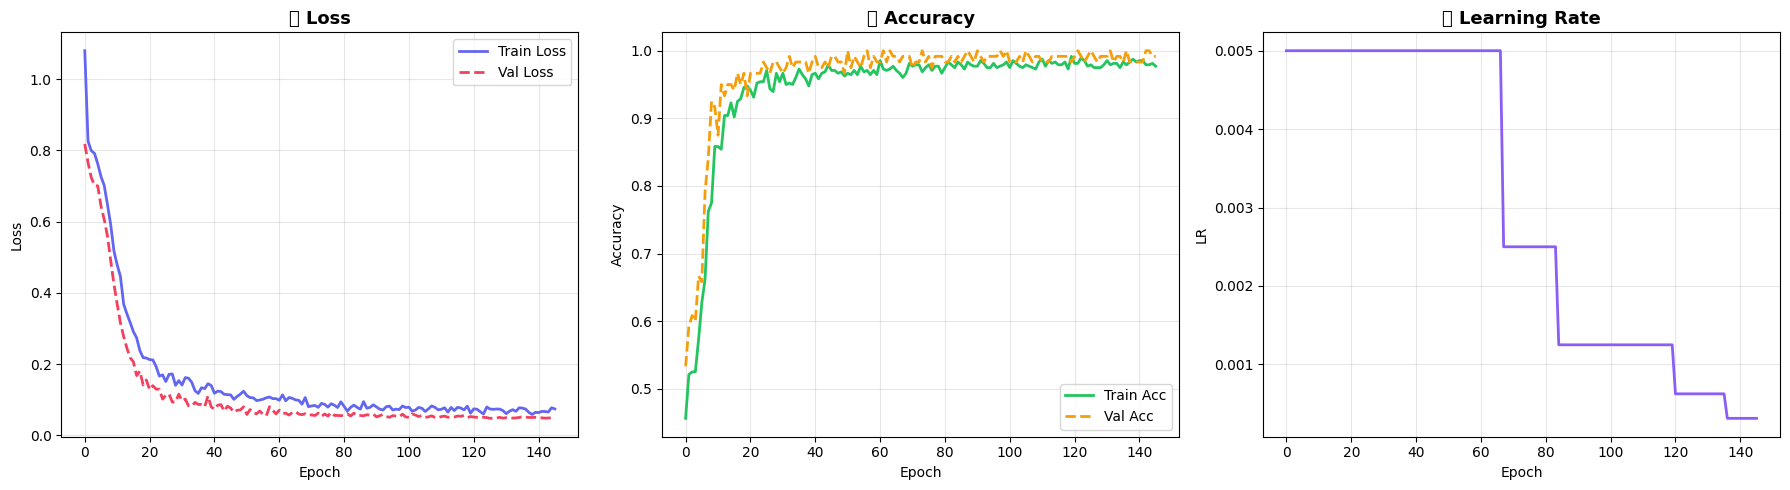

/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_12607/573619832.py:28: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


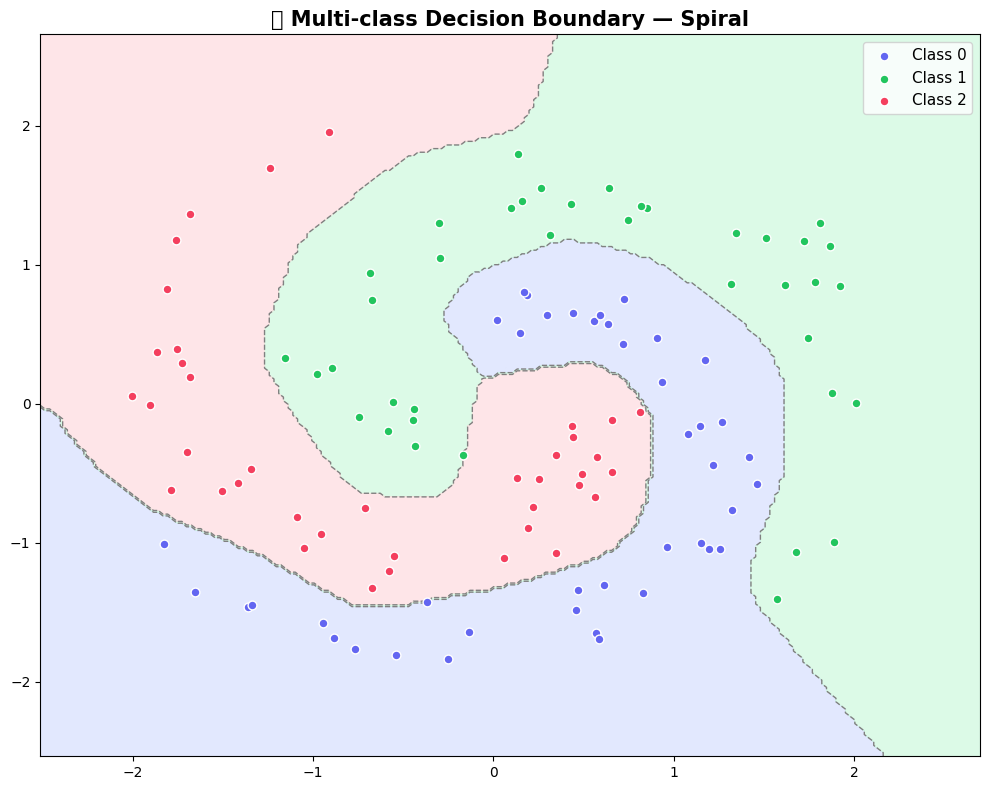


🎯 Multi-class Val Accuracy: 1.0000


In [23]:
# ============================================================
# Multi-class Results
# ============================================================

plot_training_history(history_mc)

# Decision boundary
fig, ax = plt.subplots(figsize=(10, 8))

xx, yy = np.meshgrid(
 np.linspace(X_spiral[:, 0].min() - 0.5, X_spiral[:, 0].max() + 0.5, 200),
 np.linspace(X_spiral[:, 1].min() - 0.5, X_spiral[:, 1].max() + 0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_mc = np.argmax(model_mc.predict(grid), axis=1).reshape(xx.shape)

ax.contourf(xx, yy, Z_mc, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#c7d2fe', '#bbf7d0', '#fecdd3'], alpha=0.5)
ax.contour(xx, yy, Z_mc, levels=[0.5, 1.5], colors='gray', linewidths=1, linestyles='--')

y_val_labels = np.argmax(y_val_s, axis=1)
for c in range(3):
 mask = y_val_labels == c
 ax.scatter(X_val_s[mask, 0], X_val_s[mask, 1], c=class_colors[c], 
 s=40, edgecolors='white', linewidths=1, zorder=5, label=f'Class {c}')

ax.set_title(' Multi-class Decision Boundary — Spiral', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Accuracy
val_preds_mc = model_mc.predict(X_val_s)
val_acc_mc = np.mean(np.argmax(val_preds_mc, axis=1) == np.argmax(y_val_s, axis=1))
print(f"\n Multi-class Val Accuracy: {val_acc_mc:.4f}")

---

<a id="13"></a>
## 13. Model Save & Load

Production models must be **serializable** — train once, deploy everywhere.

In [24]:
# ============================================================
# Model Persistence — Save & Load
# ============================================================

def save_model(model, filepath, config=None, metadata=None):
 """
 Save model weights and architecture.
 
 Production practice: save EVERYTHING needed to reproduce:
 - Model weights
 - Config/hyperparameters
 - Data preprocessing params (mean, std)
 - Training metadata
 """
 checkpoint = {
 'weights': [
 {p['name']: p['param'].copy() for p in layer.params()}
 for layer in model.layers
 ],
 'architecture': [repr(layer) for layer in model.layers],
 'config': config,
 'metadata': metadata or {},
 }
 
 with open(filepath, 'wb') as f:
 pickle.dump(checkpoint, f)
 
 size_kb = os.path.getsize(filepath) / 1024
 print(f" Model saved to {filepath} ({size_kb:.1f} KB)")


def load_weights(model, filepath):
 """Load saved weights into an existing model."""
 with open(filepath, 'rb') as f:
 checkpoint = pickle.load(f)
 
 for layer, saved in zip(model.layers, checkpoint['weights']):
 for p in layer.params():
 if p['name'] in saved:
 p['param'][:] = saved[p['name']]
 
 print(f" Weights loaded from {filepath}")
 return checkpoint.get('metadata', {})


# --- Demo: Save & Load ---
save_path = 'model_checkpoint.pkl'

save_model(model, save_path, 
 config={'lr': 0.005, 'batch_size': 32},
 metadata={'val_acc': metrics['accuracy'], 'val_f1': metrics['f1']})

# Verify by loading into a fresh model
model_loaded = Model()
model_loaded.add(Dense(2, 32, activation='relu'))
model_loaded.add(Dropout(rate=0.2))
model_loaded.add(Dense(32, 16, activation='relu'))
model_loaded.add(Dropout(rate=0.1))
model_loaded.add(Dense(16, 1, activation='sigmoid'))

meta = load_weights(model_loaded, save_path)

# Verify predictions match
orig_preds = model.predict(X_val[:5])
loaded_preds = model_loaded.forward(X_val[:5], training=False)
print(f"\n Verification — predictions match: {np.allclose(orig_preds, loaded_preds)}")
print(f" Loaded metadata: {meta}")

# Clean up
if os.path.exists(save_path):
 os.remove(save_path)

💾 Model saved to model_checkpoint.pkl (5.6 KB)
📦 Weights loaded from model_checkpoint.pkl

✅ Verification — predictions match: True
📋 Loaded metadata: {'val_acc': 0.99375, 'val_f1': 0.9943502824858756}


---

<a id="14"></a>
## 14. Summary

### What We Built — Production DL Framework

```
┌──────────────────────────────────────────────────────────────┐
│ PRODUCTION DL FRAMEWORK │
├──────────────────────────────────────────────────────────────┤
│ │
│ Data Pipeline │
│ ├── DataLoader (mini-batches, shuffling) │
│ └── train_val_split │
│ │
│ Layer API │
│ ├── Dense (He/Xavier init, L2 reg, grad clip) │
│ └── Dropout (inverted, train/eval modes) │
│ │
│ Activations │
│ ├── ReLU, LeakyReLU, Sigmoid, Softmax, Tanh │
│ └── All numerically stable │
│ │
│ Loss Functions │
│ ├── BinaryCrossEntropy, CategoricalCrossEntropy, MSE │
│ └── Clipped for numerical safety │
│ │
│ Optimizers │
│ ├── SGD (with momentum) │
│ └── Adam (industry standard) │
│ │
│ Training Engine │
│ ├── Mini-batch training loop │
│ ├── Train/Val monitoring │
│ ├── Early Stopping (save best weights) │
│ ├── LR Scheduling (StepDecay, ReduceOnPlateau) │
│ └── Full history tracking │
│ │
│ Evaluation │
│ ├── Accuracy, Precision, Recall, F1 │
│ ├── Confusion Matrix │
│ └── Training dashboard (loss, acc, LR curves) │
│ │
│ Persistence │
│ ├── Save/Load model weights │
│ └── Config + metadata preservation │
│ │
└──────────────────────────────────────────────────────────────┘
```

### Mapping to Real Frameworks:

| Our Implementation | PyTorch Equivalent | Keras Equivalent |
|-------------------|-------------------|------------------|
| `Dense` | `nn.Linear` + activation | `Dense(units, activation)` |
| `Dropout` | `nn.Dropout` | `Dropout(rate)` |
| `Model` | `nn.Sequential` | `Sequential()` |
| `Adam` | `optim.Adam` | `Adam()` |
| `DataLoader` | `DataLoader` | `tf.data.Dataset` |
| `EarlyStopping` | custom callback | `EarlyStopping` |
| `Trainer.fit()` | training loop | `model.fit()` |

### Production Checklist:

- [x] Reproducible (seed management)
- [x] Proper weight initialization (He/Xavier)
- [x] Mini-batch training with shuffling
- [x] Train/Val split
- [x] L2 Regularization
- [x] Dropout
- [x] Gradient clipping
- [x] Adam optimizer
- [x] Learning rate scheduling
- [x] Early stopping with best model restoration
- [x] Comprehensive metrics (P, R, F1)
- [x] Model save/load
- [x] Numerically stable operations

### What to Add for Full Production:

- Batch Normalization
- Convolutional layers (CNN)
- Recurrent layers (RNN, LSTM)
- Data augmentation
- Mixed precision training
- Distributed training
- Model versioning (MLflow, W&B)
- Logging framework (not just print)